<table>
    <tr>
        <td style="text-align:left">
            <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR9ItLTT_F-3Q30cu7ZCCoKmuFGBt22pe7pNA" alt="Logo Universidad" width="300"/>
        </td>
        <td>
            Departamento de Ciencias de la Computación y de la Decisión<br>
            Facultad de Minas<br>
            Universidad Nacional de Colombia<br>
            Optimizacion e IA 2026-2S<br><br>
            Estudiante: Juan Gabriel Carvajal Negrete<br>
            <br>
            Maestria En Ingenieria Analitica 
        </td>    
    </tr>
</table>

In [54]:
#--------------------- Importación de librerias -----------------------#
########################################################################

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
import numpy as np

## **Randon Forest sobre el conjunto de datos Digits.**

In [ ]:
# Cargar la base de datos 
digit = datasets.load_digits()

# revisamos categorias y columnas de la base de datos 
print(digit.target_names)
print(digit.feature_names)

[0 1 2 3 4 5 6 7 8 9]
['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7']


In [ ]:
# Construcción del objeto dataframe para el manejo comodo de los datos 
df_digit = pd.DataFrame(data=digit.data, columns=digit.feature_names)
df_digit["Etiqueta"] = digit.target

In [22]:
df_digit

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,Etiqueta
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [37]:
# Dividimos los datos entre entrenamiento y prueba 
X = df_digit[df_digit.columns.difference(["Etiqueta"])]
Y = df_digit.Etiqueta

# Seleccionamos el conjunto de entrenamiento (70% del total de los datos) y el conjunto de prueba (30% d elos datos)
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **(c) Optimizacion de hiperparametros usando busqueda de grilla**

In [43]:
#Creamos la grilla con los parametros a seleccionar
param_grid = {'n_estimators': np.arange(10,300,10),
              'criterion': ['gini','entropy'],
              'max_depth': [2,3,5,10,12]
}
#Defimos el clasificador base
base_estimator = RandomForestClassifier()
#Realizamos la busqueda de los hiperparametros
RF_gridSearch = GridSearchCV(base_estimator, param_grid)
#Nota: no se olviden de invocar el metodo para entrenar .fit
RF_gridSearch.fit(X_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 5, 10, 12],
                         'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260,
       270, 280, 290])})

In [44]:
# parametros sleecionados por el método

RF_gridSearch.best_params_


{'criterion': 'gini', 'max_depth': 12, 'n_estimators': np.int64(170)}

In [45]:
#Usamos el clasificador y analizamos su precision
y_pred = RF_gridSearch.best_estimator_.predict(X_test)
print("Accuracy : "), metrics.accuracy_score(y_test,y_pred)

Accuracy : 


(None, 0.9648148148148148)

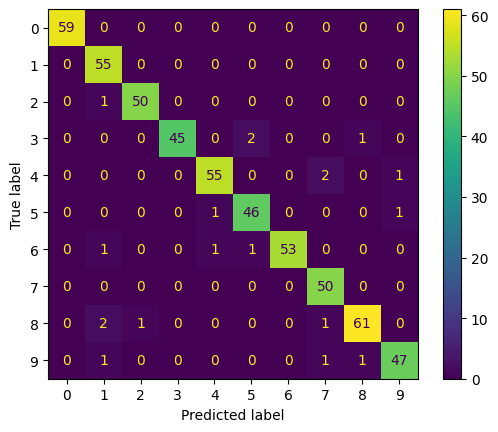

In [46]:
# Matriz de confusión 
#Otra alternativa para analizar el desempeño es la matriz de confusion
#tambien podemos calcularla desde la libreria sklearn
cm_rf = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=RF_gridSearch.best_estimator_.classes_)
disp.plot()

### **Optimizacion de hiperparametros usando busqueda aleatoria**

In [51]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {'n_estimators': np.arange(10,300,10),
              'criterion': ['gini','entropy'],
              'max_depth': [2,3,5,10,12]
              }

#Definimos el clasificador base
base_estimator = RandomForestClassifier()
#Seleccionamos los hiperparametros
RF_randomSearch = RandomizedSearchCV(base_estimator,param_grid,n_iter=15)
#Nota: despues de emplear RandomizedSearchVC tambien se requiere entrenar
#el modelo
RF_randomSearch.fit(X_train, y_train)

RandomizedSearchCV(estimator=RandomForestClassifier(), n_iter=15,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [2, 3, 5, 10, 12],
                                        'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260,
       270, 280, 290])})

In [49]:
#Revisamos los parametros seleccionados
RF_randomSearch.best_params_

{'n_estimators': np.int64(160), 'max_depth': 10, 'criterion': 'entropy'}

In [50]:
#Calculamos la precision
y_pred=RF_randomSearch.predict(X_test)
print("Accuracy - Opt", metrics.accuracy_score(y_test,y_pred))

Accuracy - Opt 0.9685185185185186


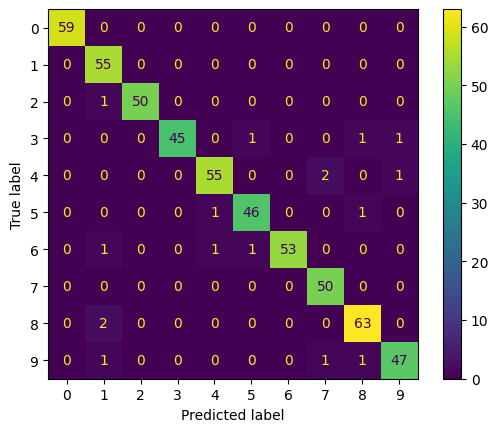

In [52]:
#Calculamos la matriz de confusion
cm_rf = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=RF_gridSearch.best_estimator_.classes_)
disp.plot()

### **Optimizacion de hiperparametros usando optimización bayesiana**

In [58]:
#Creamos la grilla con los parametros a seleccionar
param_grid = {'n_estimators':   np.arange(10,250,10),
              'criterion': ['gini','entropy'],
              'max_depth': [2,3,5,10,12]
}
#Defimos el clasificador base
base_estimator = RandomForestClassifier()
#Realizamos la busqueda de los hiperparametros
###############
RF_optBay = BayesSearchCV(base_estimator,param_grid,n_iter=15)
#Nota: no se olviden de invocar el metodo para entrenar .fit
RF_optBay.fit(X_train,y_train)

BayesSearchCV(estimator=RandomForestClassifier(), n_iter=15,
              search_spaces={'criterion': ['gini', 'entropy'],
                             'max_depth': [2, 3, 5, 10, 12],
                             'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240])})

In [57]:
#Revisamos los parametros seleccionados
RF_optBay.best_params_

OrderedDict([('criterion', 'gini'), ('max_depth', 12), ('n_estimators', 170)])

In [59]:
#Calculamos la precision
y_pred=RF_optBay.predict(X_test)
print("Accuracy - Opt", metrics.accuracy_score(y_test,y_pred))

Accuracy - Opt 0.9685185185185186


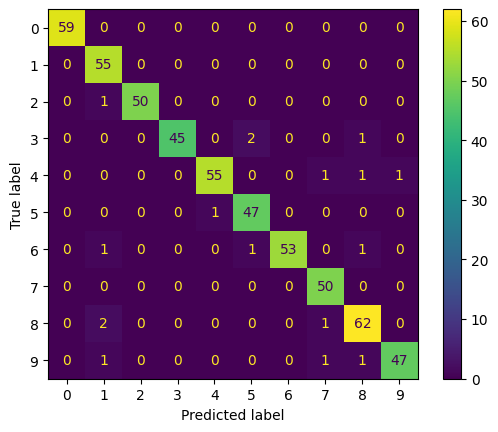

In [60]:
#Calculamos la matriz de confusion
cm_rf = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=RF_optBay.best_estimator_.classes_)
disp.plot()